# Adversarial Patch Generation - Collusion

This notebook uses a given dataset to generate an adversarial patch which is classified as a chosen class. 

## Environment

ART should be compatible with Python 3.9, 3.10 and 3.11 (https://github.com/Trusted-AI/adversarial-robustness-toolbox)

Lightning AI conda 3.9.20 Kernel and Environment 3.9.0 

Or locally Python 3.9.16

We install ART using the flag -e so we can use our own modified version, which can be cloned from: https://github.com/xHascox/adversarial-robustness-toolbox

In [1]:
%pip install -e ../adversarial-robustness-toolbox

Obtaining file:///home/nabaut/carlalite/Marco/adversarial-robustness-toolbox
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for adversarial-robustness-toolbox (pyproject.toml) ... done
  Created wheel for adversarial-robustness-toolbox: filename=adversarial_robustness_toolbox-1.18.2-0.editable-py3-none-any.whl size=7485 sha256=1761684f746387b1b368ea698646cea0d2c551dc57f3e36e8c3edfbd337e1d3e
  Stored in directory: /tmp/pip-ephem-wheel-cache-24wnhock/wheels/f6/2f/cc/55522593566b6c03fe4dd801243415d411295617b88b5202c4
Successfully built adversarial-robustness-toolbox
  Attempting uninstall: adversarial-robustness-toolbox
    Found existing installation: adversarial-robustness-toolbox 1.18.2
    Uninstalling adversarial-robustness-toolbox-1.18.2:
      Successfully uninstalled adversarial-robustness-toolbox-1.18.

In [2]:
%pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


# ART - Adversarial Patch - PyTorch - YOLO

This Notebook is based on: https://github.com/Trusted-AI/adversarial-robustness-toolbox/blob/main/notebooks/adversarial_patch/attack_adversarial_patch_pytorch_yolo.ipynb

In [3]:
import art.attacks.evasion
from art.estimators.object_detection.pytorch_yolo import PyTorchYolo
from art.attacks.evasion import AdversarialPatchPyTorch
art.attacks.evasion.__file__  # Making sure we use our version of ART

/home/nabaut/carlalite/Marco/.conda/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


'/home/nabaut/carlalite/Marco/adversarial-robustness-toolbox/art/attacks/evasion/__init__.py'

## Patch Generation

In [4]:
import yolov5
from yolov5.utils.loss import ComputeLoss

import os
import random
import numpy as np
import matplotlib.pyplot as plt

import requests
import io
from io import BytesIO
import zipfile

import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch
import torchvision
from torchvision.transforms import transforms
from tqdm import tqdm
from PIL import Image

import cv2
import matplotlib
import matplotlib.pyplot as plt


plt.style.use('ggplot')
matplotlib.use('Agg')  # Use the 'Agg' backend for headless mode

#matplotlib.use( 'tkagg' )
%matplotlib inline

Yolov5 classes etc.: https://github.com/ultralytics/yolov5/blob/master/data/coco.yaml

In [5]:
OBJECT_CATEGORY_NAMES = ['person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus', 'train', 'truck', 'boat', 'traffic light',
        'fire hydrant', 'stop sign', 'parking meter', 'bench', 'bird', 'cat', 'dog', 'horse', 'sheep', 'cow',
        'elephant', 'bear', 'zebra', 'giraffe', 'backpack', 'umbrella', 'handbag', 'tie', 'suitcase', 'frisbee',
        'skis', 'snowboard', 'sports ball', 'kite', 'baseball bat', 'baseball glove', 'skateboard', 'surfboard',
        'tennis racket', 'bottle', 'wine glass', 'cup', 'fork', 'knife', 'spoon', 'bowl', 'banana', 'apple',
        'sandwich', 'orange', 'broccoli', 'carrot', 'hot dog', 'pizza', 'donut', 'cake', 'chair', 'couch',
        'potted plant', 'bed', 'dining table', 'toilet', 'tv', 'laptop', 'mouse', 'remote', 'keyboard', 
        'cell phone', 'microwave', 'oven', 'toaster', 'sink', 'refrigerator', 'book', 'clock', 'vase', 'scissors', 
        'teddy bear', 'hair drier', 'toothbrush']  # These are the classes that Yolov5 can detect

In [6]:
OBJECT_CATEGORY_NAMES.index("car")

2

In [7]:
import pickle
# Function to load data
def load_data(file_path):
    with open(file_path, 'rb') as f:
        return pickle.load(f)

# Function to save data
def save_data(file_path, data):
    with open(file_path, 'wb') as f:
        pickle.dump(data, f)

In [8]:
def extract_predictions(predictions_, conf_thresh=0, n_boxes=5, classes=[], DEBUG=False):
    """
    Filters the predictions obtained from a model by their confidence and classes

    predictions_: The predictions from a model
    conf_thresh: Min. score for predictions to be included (float)
    n_boxes: Max. number of prediction to keep (takes the ones with highest score) (int)
    classes: classes to keep (all if empty) (list)

    Returns a tuple of (classes, boxes, scores) of the detections
    """

    # Filter by confidence threshold
    boxes = predictions_["boxes"]
    scores = predictions_["scores"]
    labels = predictions_["labels"]

    if DEBUG: print(f">>>> filtering {len(scores)} with threshold {conf_thresh}")
    filtered_indices = [i for i, score in enumerate(scores) if score >= conf_thresh]
    if len(filtered_indices) < 1:
        return [], [], []
    boxes = [boxes[i] for i in filtered_indices]
    scores = [scores[i] for i in filtered_indices]
    labels = [labels[i] for i in filtered_indices]

    # Apply Non-Maximum Suppression (NMS)
    boxes_tensor = torch.tensor(boxes)
    scores_tensor = torch.tensor(scores)
    if DEBUG: print(f">>>> running NMS with {len(scores)} scores")
    keep_indices = torchvision.ops.nms(boxes_tensor, scores_tensor, iou_threshold=0.5).tolist()

    #print(predictions_)
    
    predictions_class = [OBJECT_CATEGORY_NAMES[i] for i in labels]  # For each prediction, get the predicted class
    predictions_boxes = [[(i[0], i[1]), (i[2], i[3])] for i in boxes]  # Get the predicted bounding boxes
    predictions_score = scores  # Get the prediction score

    predictions_class = [predictions_class[i] for i in keep_indices]
    predictions_boxes = [predictions_boxes[i] for i in keep_indices]
    predictions_score = [predictions_score[i] for i in keep_indices]

    predictions_t = sorted(range(len(predictions_score)), key=lambda i: predictions_score[i], reverse=True)  # Sort the prediction indices by their score

    # Put the other lists in the same order, by descending prediction score
    predictions_boxes = [predictions_boxes[i] for i in predictions_t]
    predictions_class = [predictions_class[i] for i in predictions_t]
    predictions_scores = [predictions_score[i] for i in predictions_t]
    if classes:  # only keep the n_boxes best detections of the specified classes, if they are above the confidence threshold
        predictions_boxes_n = [e for e, c, s in zip(predictions_boxes, predictions_class, predictions_scores) if c in classes and s >= conf_thresh][:n_boxes]
        predictions_class_n = [e for e, s in zip(predictions_class, predictions_scores) if e in classes and s >= conf_thresh][:n_boxes]
        predictions_scores_n = [e for e, c in zip(predictions_scores, predictions_class) if c in classes and e >= conf_thresh][:n_boxes]
    else:  # only keep the n_boxes best detections
        predictions_boxes_n = predictions_boxes[:n_boxes]
        predictions_class_n = predictions_class[:n_boxes]
        predictions_scores_n = predictions_scores[:n_boxes]

    if DEBUG: print(f"predictions_class_n {predictions_class_n}")
    if DEBUG: print(f"predictions_boxes_n {predictions_boxes_n}")
    if DEBUG: print(f"predictions_scores_n {predictions_scores_n}")
    return predictions_class_n, predictions_boxes_n, predictions_scores_n


def plot_image_with_boxes(img, boxes, pred_cls, title, scores, color=(0,255,0), colordict={}, target_boxes=None):
    """
    Visualizes an image with the detected object boxes

    img: Image to plot
    boxes: Prediction boxes (from extract_predictions)
    pred_cls: Class (from extract_predictions)
    title: The plot title (str)
    scores: Score (from extract_predictions)
    color: Default color value for the boxes (tuple)
    colordict: Dictionary with box colors for some classes (dict) like {"car":(255,0,0)}
    """
    text_size = 1
    text_th = 3
    rect_th = 4

    for i in range(len(boxes)):
        if target_boxes is not None:
            #print("target_boxes[i])", target_boxes)
            cv2.rectangle(img, (int(target_boxes[0]), int(target_boxes[1])), (int(target_boxes[2]), int(target_boxes[3])),
                        color=(255,255,0), thickness=rect_th//2)
            
        cv2.rectangle(img, (int(boxes[i][0][0]), int(boxes[i][0][1])), (int(boxes[i][1][0]), int(boxes[i][1][1])),
                      color=colordict.get(pred_cls[i], color), thickness=rect_th)
        # Write the prediction class
        cv2.putText(img, pred_cls[i]+" "+f"{scores[i]:.2f}", (int(boxes[i][0][0]), int(boxes[i][0][1])), cv2.FONT_HERSHEY_SIMPLEX, text_size,
                    colordict.get(pred_cls[i], color), thickness=text_th) 
        

    plt.figure(dpi=200)
    plt.axis("off")
    plt.title(title)
    plt.imshow(img.astype(np.uint8), interpolation="nearest")



Check available GPU:

In [9]:
if torch.cuda.is_available():
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")
    print(f"GPU Count: {torch.cuda.device_count()}")
else:
    print("No GPU found.")

GPU Name: NVIDIA GeForce RTX 3070
GPU Count: 1


Define the model to attack

In [10]:
NUMBER_CHANNELS = 3
INPUT_SHAPE = (NUMBER_CHANNELS, 2048, 2048) # For some reason, this only really works for square images, (512, 1024) used to work

In [11]:
yolov5.utils.general.non_max_suppression

<function yolov5.utils.general.non_max_suppression(prediction, conf_thres=0.25, iou_thres=0.45, classes=None, agnostic=False, multi_label=False, labels=(), max_det=300, nm=0)>

In [12]:
class Yolo(torch.nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model
        self.model.hyp = {'box': 0.05,
                        'obj': 1.0,
                        'cls': 0.5,
                        'anchor_t': 4.0,
                        'cls_pw': 1.0,
                        'obj_pw': 1.0,
                        'fl_gamma': 0.0
                        }
        self.compute_loss = ComputeLoss(self.model.model.model)

    def forward(self, x, targets=None):
        if self.training:
            #print("self.training is true")
            outputs = self.model.model.model(x)
            loss, loss_items = self.compute_loss(outputs, targets)
            loss_components_dict = {"loss_total": loss}
            loss_components_dict['loss_box'] = loss_items[0]
            loss_components_dict['loss_obj'] = loss_items[1]
            loss_components_dict['loss_cls'] = loss_items[2]
            return loss_components_dict
        else:
            #print("self.training is false")
            #return self.model(x)
            outputs = self.model(x)

            # Apply non-maximum suppression
            # Default NMS settings: conf_thres=0.25, iou_thres=0.45; adjust as needed
            #results = yolov5.utils.general.non_max_suppression(outputs, conf_thres=0.25, iou_thres=0.45)
            return outputs#results

model = yolov5.load('yolov5s.pt')
#model2 = yolov5.load('best.pt')
#model = torch.hub.load('ultralytics/yolov5', 'custom', 'best.pt')

model = Yolo(model)

detector = PyTorchYolo(model=model,
                    device_type='gpu',
                    input_shape=INPUT_SHAPE,
                    clip_values=(0, 255), 
                    attack_losses=("loss_total", "loss_cls",
                                    "loss_box",
                                    "loss_obj"))

Fix the seed

In [13]:
# Set the seed for randomness
seed = 42

# Set the seed for PyTorch
torch.manual_seed(seed)

# If you are using CUDA
if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)  # for all GPUs

# Set the seed for NumPy
np.random.seed(seed)

# Set the seed for Python's built-in random module
random.seed(seed)

In [14]:
# directory containing the training images
DATASET_URL_V1 = "https://storage.googleapis.com/weebit-shared/ParkingCrossingPedestrian.zip"
DATASET_URL_V4 = "https://storage.googleapis.com/weebit-shared/dsv4.zip"
DATASET_URL_V5 = "https://storage.googleapis.com/weebit-shared/dsv5.zip"
DATASET_V1 = "O:\Place\MasterThesis\PatchDataset\PatchDataset"
DATASET_V4 = "DSV2"
DATASET_V5 = "./datasets/DSV5"

DATASET_URL = DATASET_URL_V5
TRAINING_DATASET_DIR = DATASET_V5

LARGE_DATASET = True # TODO this is unused
DATASET_CUTOFF_GENERATE = 0 # 20
DATASET_CUTOFF = 0
# './train img/'
# "D:\CarlaGarageData\PatchDataset"

In [15]:
"""
Here, we download the Patch Dataset from remote if it does not already exist on disk, as specified by TRAINING_DATASET_DIR.
"""
# Define the folder and URL
folder_path = TRAINING_DATASET_DIR
zip_url = DATASET_URL

# Check if folder exists
if not os.path.exists(folder_path):
    print(f"{folder_path} does not exist. Downloading ZIP from {zip_url}...")

    # Stream the download and write to a file
    with requests.get(zip_url, stream=True) as response:
        response.raise_for_status()  # Check for HTTP errors
        total_size = int(response.headers.get('content-length', 0))
        chunk_size = 1024 * 1024 * 128 # 128 MB

        # Write to a temp file for large size
        with tqdm(total=total_size//(1024*1024), unit='MB', unit_scale=True, desc='Downloading') as progress_bar:
            temp_zip_path = "temp_download.zip"
            with open(temp_zip_path, 'wb') as file:
                for chunk in response.iter_content(chunk_size=chunk_size):
                    if chunk:  # Filter out keep-alive chunks
                        file.write(chunk)
                        progress_bar.update(len(chunk)//(1024*1024))


    # Now extract the ZIP file
    print("Extracting the files...")
    with zipfile.ZipFile(temp_zip_path, 'r') as zip_ref:
        zip_ref.extractall(folder_path)

    # Optionally remove the zip file after extraction
    os.remove(temp_zip_path)
    print(f"Content extracted to {folder_path}.")
else:
    print(f"{folder_path} already exists. No need to download.")

./datasets/DSV5 already exists. No need to download.


In [16]:
def filter_boxes(predictions, conf_thresh): # TODO WHY IS THIS NEEDED?
    dictionary = {}

    boxes_list = []
    scores_list = []
    labels_list = []

    for i in range(len(predictions[0]["boxes"])):
        score = predictions[0]["scores"][i]
        if score >= conf_thresh:
            boxes_list.append(predictions[0]["boxes"][i])
            scores_list.append(predictions[0]["scores"][[i]])
            labels_list.append(predictions[0]["labels"][[i]])

    #dictionary["boxes"] = np.vstack(boxes_list)
    if boxes_list:  # Check if boxes_list is not empty
        dictionary["boxes"] = np.vstack(boxes_list)
        dictionary["scores"] = np.hstack(scores_list)
        dictionary["labels"] = np.hstack(labels_list)
    else:
        dictionary["boxes"] = np.empty((0,))  # Assign an empty array if boxes_list is empty
        dictionary["scores"] = np.empty((0,))
        dictionary["labels"] = np.empty((0,))

    y = [dictionary]

    return y

In [17]:
import warnings

# Ignore all future warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
# Reason:
# Adversarial-Patch-ART\.venv\Lib\site-packages\yolov5\models\common.py:682: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
#  with amp.autocast(autocast):

urls = []

# Iterate over all files and directories in the given path
for root, dirs, files in os.walk(TRAINING_DATASET_DIR):
    for file in files:
        file_path = os.path.join(root, file)
        print(file_path)  # Do something with the file path
        urls+=[file_path]

print("Size of Dataset:", len(urls))

if not DATASET_CUTOFF:
    DATASET_CUTOFF = len(urls)

# Calculate padding, assumes all images in the training set have the same resolution
train_img_height = Image.open(urls[0]).height
padding_top = (INPUT_SHAPE[1] - train_img_height) // 2
padding_bottom = INPUT_SHAPE[1] - train_img_height - padding_top

transform = transforms.Compose([
        #transforms.Resize(INPUT_SHAPE[1], interpolation=transforms.InterpolationMode.BICUBIC),
        #transforms.CenterCrop(INPUT_SHAPE[1]),
        transforms.Pad((0, padding_top, 0, padding_bottom)),
        transforms.ToTensor(),
        transforms.Lambda(lambda x: x[:3])  # Keep only the first 3 channels (RGB)
    ])
print("###")
print(transform)

def load_and_transform_image(url):
    im = Image.open(url)
    return transform(im).numpy()

def batch_predict(urls, batch_size):
    all_predictions = []
    for i in tqdm(range(0, len(urls), batch_size), desc="Loading, transforming and predicting Batches"):
        batch_urls = urls[i:i + batch_size]
        batch_images = np.array([load_and_transform_image(url) for url in batch_urls])*255
        batch_dets = detector.predict(batch_images)
        all_predictions.extend(batch_dets)
    return all_predictions

sampled_urls = random.sample(urls, DATASET_CUTOFF if DATASET_CUTOFF > 0 and DATASET_CUTOFF <= len(urls) else len(urls))

from sklearn.model_selection import train_test_split

# Use train_test_split to split the data
train_urls, validation_urls = train_test_split(
    sampled_urls, test_size=0.2, random_state=42
)

training_images_for_generation = train_urls

if DATASET_CUTOFF_GENERATE:
    training_images_for_generation = training_images_for_generation[:DATASET_CUTOFF_GENERATE]

print("After cutoff for Generation:", len(training_images_for_generation))

batch_size = 1
dets = batch_predict(training_images_for_generation, batch_size)

torch.cuda.empty_cache()

#dets2 = detector2.predict(coco_images) 
filter_threshold = 0.5
#y = [filter_boxes([t], filter_threshold)[0] for t in tqdm(dets, desc=f"Filtering Predictions threshold {filter_threshold}")]

y_stored = "y.pickle"
# Check if the file exists
if os.path.exists(y_stored):
    # Load from disk
    y = load_data(y_stored)
    print("y loaded from ", y_stored)
else:
    # Get data and store to disk for later use
    y = [filter_boxes([t], filter_threshold)[0] for t in tqdm(dets, desc=f"Filtering Predictions threshold {filter_threshold}")]
    save_data(y_stored, y)
    print("Data retrieved and saved to disk:", y_stored)

./datasets/DSV5/dsv5/Town05_041532.png
./datasets/DSV5/dsv5/Town05_042001.png
./datasets/DSV5/dsv5/Town04_039310.png
./datasets/DSV5/dsv5/Town01_037301.png
./datasets/DSV5/dsv5/Town01_036698.png
./datasets/DSV5/dsv5/Town05_041275.png
./datasets/DSV5/dsv5/Town05_040671.png
./datasets/DSV5/dsv5/Town01_036247.png
./datasets/DSV5/dsv5/Town02_038260.png
./datasets/DSV5/dsv5/Town05_042033.png
./datasets/DSV5/dsv5/Town01_036013.png
./datasets/DSV5/dsv5/Town01_034893.png
./datasets/DSV5/dsv5/Town02_037756.png
./datasets/DSV5/dsv5/Town04_039306.png
./datasets/DSV5/dsv5/Town04_040467.png
./datasets/DSV5/dsv5/Town01_035741.png
./datasets/DSV5/dsv5/Town04_039594.png
./datasets/DSV5/dsv5/Town04_040119.png
./datasets/DSV5/dsv5/Town01_034887.png
./datasets/DSV5/dsv5/Town01_035667.png
./datasets/DSV5/dsv5/Town02_037439.png
./datasets/DSV5/dsv5/Town02_037696.png
./datasets/DSV5/dsv5/Town01_035219.png
./datasets/DSV5/dsv5/Town05_042055.png
./datasets/DSV5/dsv5/Town03_038849.png
./datasets/DSV5/dsv5/Town

Loading, transforming and predicting Batches: 100%|██████████| 1213/1213 [03:21<00:00,  6.01it/s]


y loaded from  y.pickle


In [18]:
train_img_height

1024

In [19]:
INPUT_SHAPE

(3, 2048, 2048)

In [20]:
y[-1]

{'boxes': array([[     1300.7,      1033.4,      1336.4,      1136.8],
        [     1301.4,      1034.2,      1335.8,      1137.9],
        [     1217.4,        1042,      1253.3,      1153.1],
        [     1301.2,      1033.1,      1336.1,      1137.1],
        [     1301.8,      1033.5,      1336.7,      1137.5],
        [     1210.9,      1045.4,      1256.2,      1154.5],
        [     1211.8,      1045.6,      1256.8,      1154.1],
        [     1300.6,      1033.2,      1336.3,      1138.2],
        [     1215.1,        1046,      1257.6,      1154.7],
        [     1301.4,      1033.3,        1336,      1136.9],
        [     1301.8,      1033.5,      1336.6,      1137.7],
        [     1210.8,      1045.5,      1256.4,      1154.6],
        [     1211.7,      1045.6,        1257,      1154.2],
        [     1300.8,      1033.1,      1336.2,      1138.3],
        [     1215.2,        1046,      1257.7,      1154.5],
        [     1301.3,      1033.7,      1336.1,      1136.7],

In [21]:

#- boxes [N, 4]: the boxes in [x1, y1, x2, y2] format, with 0 <= x1 < x2 <= W and 0 <= y1 < y2 <= H.

In [ ]:
GENERATE = True

DISGUISE_PATH = "./disguises/mountain_1.jpg"


DISGUISE_PATH = "./disguises/hibiscus.jpg"
DISGUISE_PATH = "./disguises/apple.jpg"
DISGUISE_PATH = "./disguises/raspberry.jpg"
DISGUISE_PATH = "./disguises/redhat.jpg"
DISGUISE_PATH = "./disguises/rose.jpg"
DISGUISE_PATH = "./disguises/dhalia.jpg"
DISGUISE_PATH = "./disguises/camellia.jpg"
DISGUISE_PATH = "./disguises/die.jpg"
#DISGUISE_PATH = None
USE_PRETRAINED = None#"patch_as_image_stop_sign_lr_0.01_200it.png"
USE_PRETRAINED = "patch_as_image_stop_sign_contrast_1.png"
USE_PRETRAINED = "patch_stop_dist_PD_128_25e_0.005_split.png"
USE_PRETRAINED = "patch_as_image.png"
USE_PRETRAINED = DISGUISE_PATH
#USE_PRETRAINED = DISGUISE_PATH
#USE_PRETRAINED = "patch_as_image.png"#DISGUISE_PATH
#USE_PRETRAINED = "patch_stop_dist_PD_128_16e_split.png"
#USE_PRETRAINED = "patch_stop_dist_PD_128_25e_0.005_split.png"

# ONLY RELEVANT IF GENERATE=FALSE
PATCH_PATH = "patch_as_image.png"
PATCH_PATH = "patch_stop_dist_PD_128_25e_0.005_split.png"
PATCH_PATH = "patch_as_rose_2.png"
#PATCH_PATH = "patch_as_image_stop_dist_50k_small_0.02.png"
#PATCH_PATH = "patch_stop_dist_PD_128_25e_0.005_split.png"

def create_detector_model():
    model2 = yolov5.load('yolov5s.pt')
    model2 = Yolo(model2)
    detector2 = PyTorchYolo(model=model2,
                    device_type='gpu',
                    input_shape=INPUT_SHAPE,
                    clip_values=(0, 255), 
                    attack_losses=("loss_total", "loss_cls",
                                    "loss_box",
                                    "loss_obj"))
    return detector2

In [23]:
preds_orig_person_stored = "preds_orig_person.pickle"
# Check if the file exists
if os.path.exists(preds_orig_person_stored):
    # Load from disk
    preds_orig_person = load_data(preds_orig_person_stored)
    print("preds_orig_person loaded from ", preds_orig_person_stored)
else:
    # Get data and store to disk for later use
    preds_orig_person = [extract_predictions(d, 0.1, n_boxes=2, classes=["person"]) for d in tqdm(dets, desc="Getting Person Locations of Training Images")]
    save_data(preds_orig_person_stored, preds_orig_person)
    print("Data retrieved and saved to disk:", preds_orig_person_stored)


preds_orig_person loaded from  preds_orig_person.pickle


In [24]:
rotation_max=5#20#20 # 0.0 # degrees
rotation_max=20
scale_min=0.05#0.03 # 0.05
scale_max=0.10
scale_min=0.025#0.03 # 0.05
scale_max=0.035
distortion_scale_max=0.2#.2#.3 # [0,1]
distortion_scale_max = 0.2
learning_rate=0.01#0.001 #1.99 # 0.003
learning_rate=0.03
max_epochs=15#0#0000 #1000 # 50000 gives a good result
max_steps = 0
if not GENERATE:
    max_epochs = 1
    max_steps = 1
batch_size=1 # For 2080 TI: 13, similar speed to L4 with batch size 10
patch_type="square"
optimizer="Adam" # pgd and Adam
scheduler = "CosineAnnealingWarmRestarts" # or StepLR
decay_rate=1.0
decay_step=max_epochs
patch_location=(400, 200) # TODO
targeted = True
patch_shape=(3, 512, 512)#(3, 128, 128) or 512
contrast_min = 0.8#0.4 physical
contrast_max = 0.99#0.7 physical
if DISGUISE_PATH:
    disguise = np.array(Image.open(DISGUISE_PATH).resize(patch_shape[1:]))
    disguise = disguise.transpose(2,0,1)
else:
    disguise = None
disguise_distance_factor = 1/300000#000 # 1/30000 for 128, 1/200000 for 512
# 0.0005 was too much for stop mountain
split = False
fixed_location_random_scaling = True
gap_size = 50
fixed_gap = True


#- boxes [N, 4]: the boxes in [x1, y1, x2, y2] format, with 0 <= x1 < x2 <= W and 0 <= y1 < y2 <= H.

synthetic_y = {'boxes': np.array([[     patch_location[0],      patch_location[1],      patch_location[0]+patch_shape[1],      patch_location[1]+patch_shape[2]]], dtype=np.float32),
 'scores': np.array([    1], dtype=np.float32),
 'labels': np.array([OBJECT_CATEGORY_NAMES.index("stop sign")])} # person = 0, stop sign = 11, banana = 46

patch_location=None # TODO make it work for fixed location, the scaling fails

print("USING:", detector.device)

pretrained_patch = None
if USE_PRETRAINED:
    pretrained_patch=np.array(Image.open(USE_PRETRAINED).resize(patch_shape[1:]))
    pretrained_patch = pretrained_patch.transpose(2,0,1)


ap = AdversarialPatchPyTorch(estimator=detector, rotation_max=rotation_max, 
                      scale_min=scale_min, scale_max=scale_max, optimizer=optimizer, scheduler=scheduler, distortion_scale_max=distortion_scale_max, 
                      learning_rate=learning_rate, max_epochs=max_epochs, max_steps=max_steps, batch_size=batch_size, summary_writer=False, contrast_min = contrast_min, contrast_max = contrast_max,# TODO
                      patch_shape=patch_shape, patch_type=patch_type, verbose=True, targeted=targeted, pretrained_patch=pretrained_patch, disguise=disguise, disguise_distance_factor=disguise_distance_factor,
                      split=split, gap_size=gap_size, fixed_gap=fixed_gap) # TODO
 
if GENERATE:
    patch_locations = preds_orig_person
    #patch_locations = []
    model_params = yolov5.load('yolov5s.pt')
    patch, patch_mask, loss = ap.generate(x=training_images_for_generation, y=[synthetic_y for i in range(len(training_images_for_generation))], transform=transform, patch_locations=patch_locations, fixed_location_random_scaling=fixed_location_random_scaling, detector_creator=create_detector_model, decay_rate=decay_rate, decay_step=decay_step) # 11 is stop sign used as goal target for training the patch (the dataset must then be classified as that)
    #patch, patch_mask = ap.generate(x=training_images_for_generation, y=dets) # untargeted
    # use dets or y with a good threshold as the tarets if using without location TODO
else:
    patch, patch_Smask, loss = ap.generate(x=training_images_for_generation, y=[synthetic_y for i in range(len(training_images_for_generation))], transform=transform,) # 11 is stop sign used as goal target for training the patch (the dataset must then be classified as that)
    patch=np.array(Image.open(PATCH_PATH)) # load external patch
    patch = patch.transpose(2,0,1)

 

USING: cuda:0
USING DEVICE: cuda:0


Training Steps in Epoch 1/15. Previous Loss: nan LR = 0.030000 Sched BASE LR: 0.030000: 100%|██████████| 1213/1213 [12:39<00:00,  1.60it/s]
Training Steps in Epoch 2/15. Previous Loss: 312.01233357191086 LR = 0.029672 Sched BASE LR: 0.030000: 100%|██████████| 1213/1213 [13:01<00:00,  1.55it/s]
Training Steps in Epoch 3/15. Previous Loss: 289.3722918331623 LR = 0.028703 Sched BASE LR: 0.030000: 100%|██████████| 1213/1213 [12:53<00:00,  1.57it/s]
Training Steps in Epoch 4/15. Previous Loss: 301.52219092845917 LR = 0.027135 Sched BASE LR: 0.030000: 100%|██████████| 1213/1213 [12:59<00:00,  1.56it/s]
Training Steps in Epoch 5/15. Previous Loss: 291.965658724308 LR = 0.025037 Sched BASE LR: 0.030000: 100%|██████████| 1213/1213 [13:02<00:00,  1.55it/s]
Training Steps in Epoch 6/15. Previous Loss: 274.23987402021885 LR = 0.022500 Sched BASE LR: 0.030000: 100%|██████████| 1213/1213 [12:49<00:00,  1.58it/s]
Training Steps in Epoch 7/15. Previous Loss: 259.19701224565506 LR = 0.019635 Sched BASE

In [25]:
OBJECT_CATEGORY_NAMES[46]

'banana'

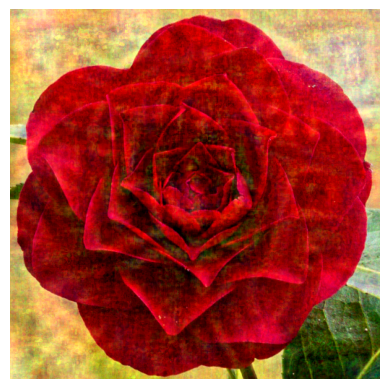

In [26]:
try:
    plt.axis("off")
    plt.imshow(((patch) * patch_mask).transpose(1,2,0).astype(np.uint8))
    plt.show()
except:
    pass

In [27]:
loss_history = []
for epoch in loss:
    loss_history.append(sum(epoch))
loss_history = np.array(loss_history)

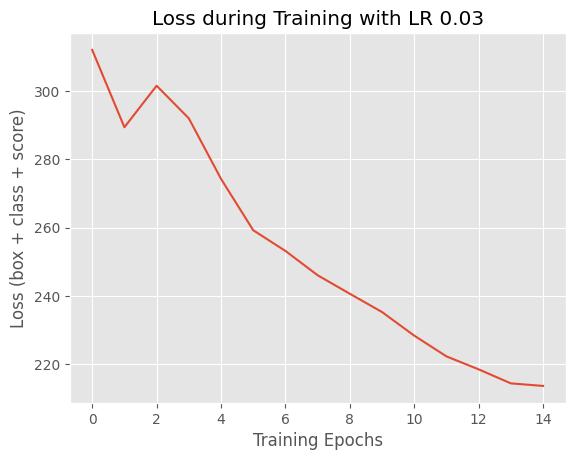

In [28]:
%matplotlib inline
plt.plot(loss_history * (-1 if optimizer=="pgd" else 1))
plt.xlabel("Training Epochs")  # Label the implicit x-axis
plt.ylabel("Loss (box + class + score)")
plt.title(f"Loss during Training with LR {learning_rate}")
plt.show()

In [29]:
flat_loss = [batch_loss for epoch in loss for batch_loss in epoch] # flatten the loss history (it contains loss per patch in a list per epoch)
flat_loss = np.array(flat_loss) * (-1 if optimizer=="pgd" else 1)

# Define the size of the sliding window
k = 10#500

# Calculate the moving average
moving_averages = np.convolve(flat_loss, np.ones(k)/k, mode='valid')

# Indices for the moving average to align with the input list
average_indices = range(k - 1, len(flat_loss))

In [30]:
ap.detailed_loss_history["disguise"]

[0.0,
 17.71379852294922,
 30.959701538085938,
 45.995872497558594,
 61.70037078857422,
 77.10670471191406,
 92.29560089111328,
 107.44283294677734,
 122.99297332763672,
 138.77110290527344,
 154.75852966308594,
 170.52102661132812,
 186.40036010742188,
 202.5727081298828,
 218.96231079101562,
 235.39651489257812,
 251.94554138183594,
 268.6456298828125,
 285.291015625,
 302.05096435546875,
 319.04425048828125,
 336.17315673828125,
 353.4996643066406,
 370.8254699707031,
 388.3218994140625,
 406.03460693359375,
 424.0263671875,
 442.3119201660156,
 460.88861083984375,
 479.7779235839844,
 498.9889831542969,
 518.519775390625,
 538.3135986328125,
 558.3101196289062,
 578.471923828125,
 598.7916259765625,
 619.2465209960938,
 639.8256225585938,
 660.5419921875,
 681.3837890625,
 702.3436889648438,
 723.4127197265625,
 744.5901489257812,
 765.8731689453125,
 787.2462158203125,
 808.6690673828125,
 830.1389770507812,
 851.6294555664062,
 873.134033203125,
 894.6549682617188,
 916.206481933

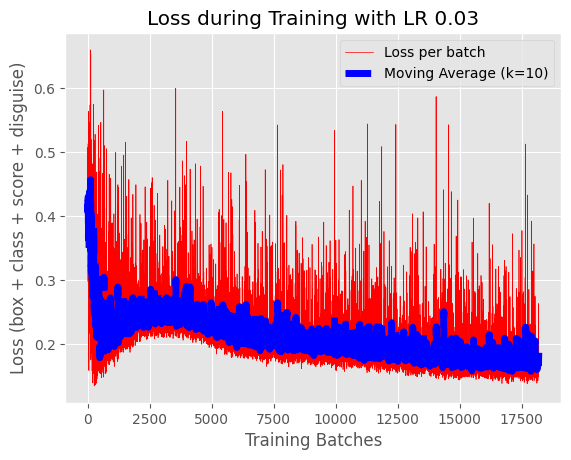

In [31]:
%matplotlib inline
try:
    plt.plot(flat_loss, linewidth=0.5, color=("red"), label="Loss per batch")
    #plt.scatter(range(len(flat_loss)), flat_loss)
    plt.plot(average_indices, moving_averages, linestyle='--', color='blue', linewidth=5, label=f'Moving Average (k={k})')


    plt.xlabel("Training Batches")  # Label the implicit x-axis
    plt.ylabel("Loss (box + class + score + disguise)")
    plt.legend()
    plt.title(f"Loss during Training with LR {learning_rate}")
    plt.show()
except Exception as e:
    print("failed to plot avg:", e)

In [32]:
Image.fromarray(patch.transpose(1,2,0).astype(np.uint8)).save("patch_as_image.png")

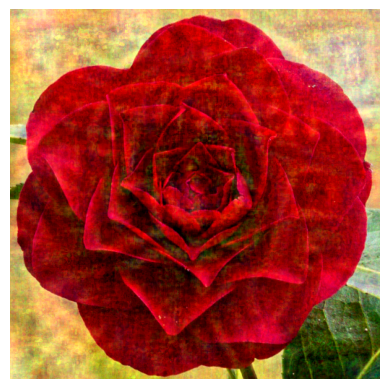

In [33]:
plt.axis("off")
plt.imshow((patch).transpose(1,2,0).astype(np.uint8))
plt.savefig("patch.png", bbox_inches='tight', pad_inches=0)


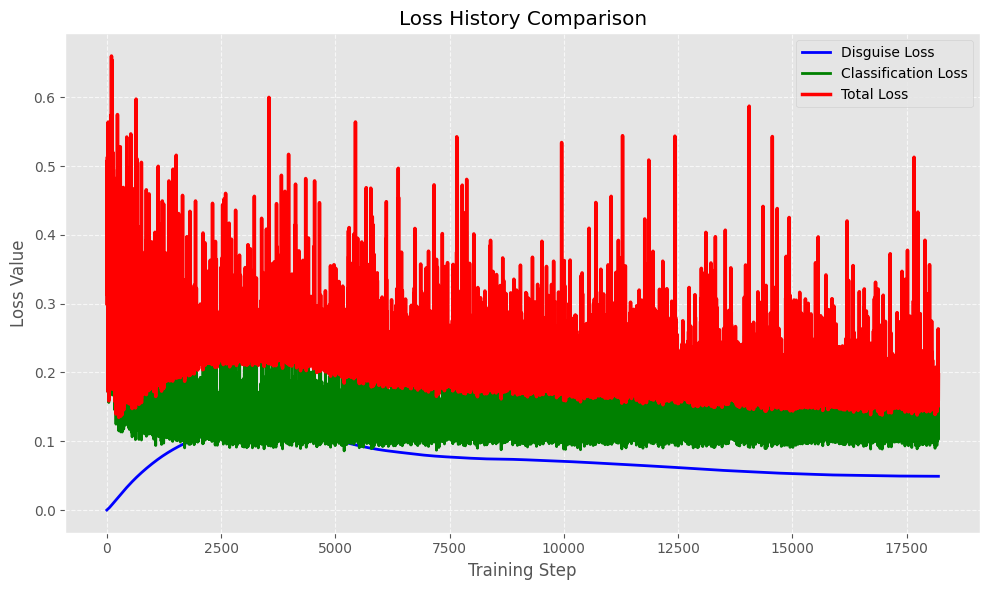

In [34]:
try:
    # Calculate the sum of both losses
    total_losses = [d + c for d, c in zip((i * disguise_distance_factor for i in ap.detailed_loss_history["disguise"]), ap.detailed_loss_history["classification"])]

    # Create steps for x-axis
    steps = list(range(1, len(total_losses) + 1))

    # Create the plot
    plt.figure(figsize=(10, 6))

    # Plot the three lines
    plt.plot(steps, [i * disguise_distance_factor for i in  ap.detailed_loss_history["disguise"]], 'b-', linewidth=2, label='Disguise Loss')
    plt.plot(steps, ap.detailed_loss_history["classification"], 'g-', linewidth=2, label='Classification Loss')
    plt.plot(steps, total_losses, 'r-', linewidth=2.5, label='Total Loss')

    # Add labels and title
    plt.xlabel('Training Step')
    plt.ylabel('Loss Value')
    plt.title('Loss History Comparison')

    # Add grid
    plt.grid(True, linestyle='--', alpha=0.7)

    # Add legend
    plt.legend()

    # Adjust layout
    plt.tight_layout()

    # Show the plot
    plt.show()

    # If you want to save the figure
    # plt.savefig('loss_history.png', dpi=300, bbox_inches='tight')
except Exception as e:
    print(e)

In [35]:
def set_seed(seed=42):
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)  # for all GPUs
    np.random.seed(seed)
    random.seed(seed)


In [36]:
#del ap
import gc
gc.collect()
torch.cuda.empty_cache()
print(torch.cuda.memory_summary(device=torch.cuda.current_device()))

|===========================================================================|
|                  PyTorch CUDA memory summary, device ID 0                 |
|---------------------------------------------------------------------------|
|            CUDA OOMs: 0            |        cudaMalloc retries: 0         |
|===========================================================================|
|        Metric         | Cur Usage  | Peak Usage | Tot Alloc  | Tot Freed  |
|---------------------------------------------------------------------------|
| Allocated memory      | 113873 KiB |   4686 MiB | 197262 GiB | 197262 GiB |
|       from large pool |  71808 KiB |   4440 MiB | 196323 GiB | 196323 GiB |
|       from small pool |  42065 KiB |    247 MiB |    939 GiB |    939 GiB |
|---------------------------------------------------------------------------|
| Active memory         | 113873 KiB |   4686 MiB | 197262 GiB | 197262 GiB |
|       from large pool |  71808 KiB |   4440 MiB | 196323 GiB |

In [37]:
#### TODO RM THIS IS JUST FOR DEBUGGING SHOULD WORK WITHOUT!!!
"""
model2 = yolov5.load('yolov5s.pt')
#model2 = yolov5.load('best.pt')
#model = torch.hub.load('ultralytics/yolov5', 'custom', 'best.pt')

model2 = Yolo(model2)

detector2 = PyTorchYolo(model=model2,
                    device_type='gpu',
                    input_shape=INPUT_SHAPE,
                    clip_values=(0, 255), 
                    attack_losses=("loss_total", "loss_cls",
                                    "loss_box",
                                    "loss_obj"))

def compare_models(model1, model2):
    # Ensure both models are in evaluation mode

    
    identical = True

    for (name1, param1), (name2, param2) in zip(model1.model.named_parameters(), model2.model.named_parameters()):
        if name1 != name2:
            print(f"Parameter names differ: {name1} vs {name2}")
            identical = False
            break
        if not torch.equal(param1, param2):
            print(f"Parameters differ at: {name1}")
            identical = False
            break

    if identical:
        print("Models are identical.")
    else:
        print("Models differ.")

# Example to use the function
# model1 = ... # your first model
# model2 = ... # your second model
compare_models(detector, detector2)
"""

'\nmodel2 = yolov5.load(\'yolov5s.pt\')\n#model2 = yolov5.load(\'best.pt\')\n#model = torch.hub.load(\'ultralytics/yolov5\', \'custom\', \'best.pt\')\n\nmodel2 = Yolo(model2)\n\ndetector2 = PyTorchYolo(model=model2,\n                    device_type=\'gpu\',\n                    input_shape=INPUT_SHAPE,\n                    clip_values=(0, 255), \n                    attack_losses=("loss_total", "loss_cls",\n                                    "loss_box",\n                                    "loss_obj"))\n\ndef compare_models(model1, model2):\n    # Ensure both models are in evaluation mode\n\n\n    identical = True\n\n    for (name1, param1), (name2, param2) in zip(model1.model.named_parameters(), model2.model.named_parameters()):\n        if name1 != name2:\n            print(f"Parameter names differ: {name1} vs {name2}")\n            identical = False\n            break\n        if not torch.equal(param1, param2):\n            print(f"Parameters differ at: {name1}")\n            iden

TODO: Compare to only the disguise and count the ASR (Attack SUccess Rate)

TODO: Not simply counting all stop sign scores

Validation of the trained patch:

val steps: 100%|██████████| 304/304 [04:34<00:00,  1.11it/s]


STATS
Number of attacks: 304
Successful attacks: 98
Success rate: 0.3223684210526316


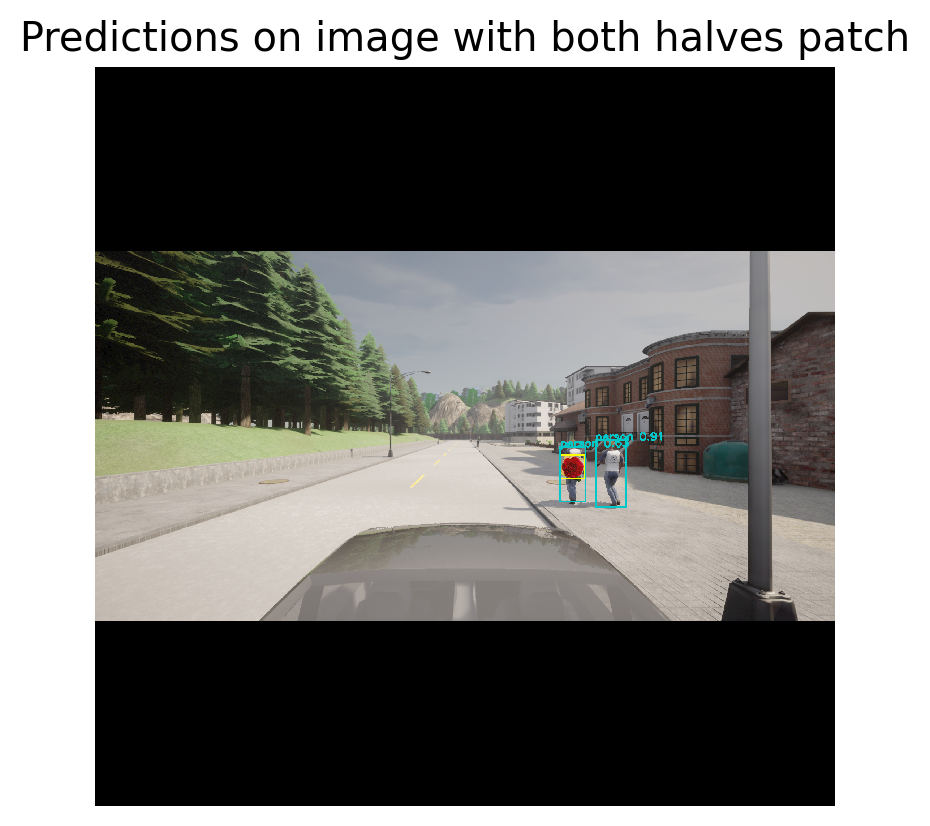

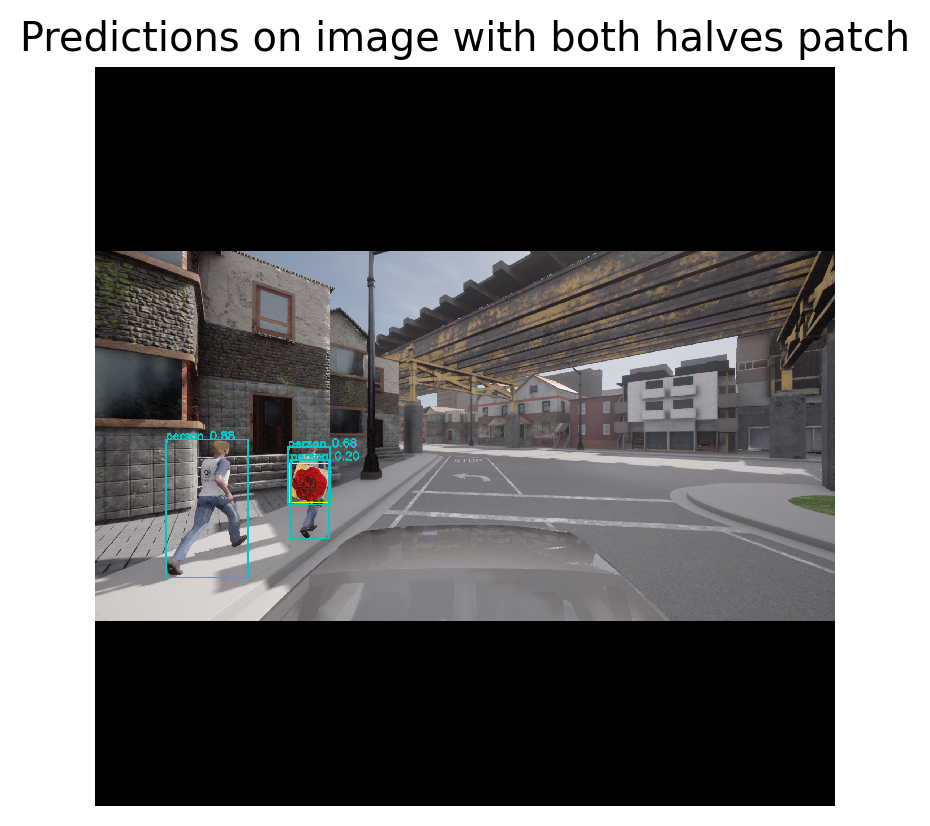

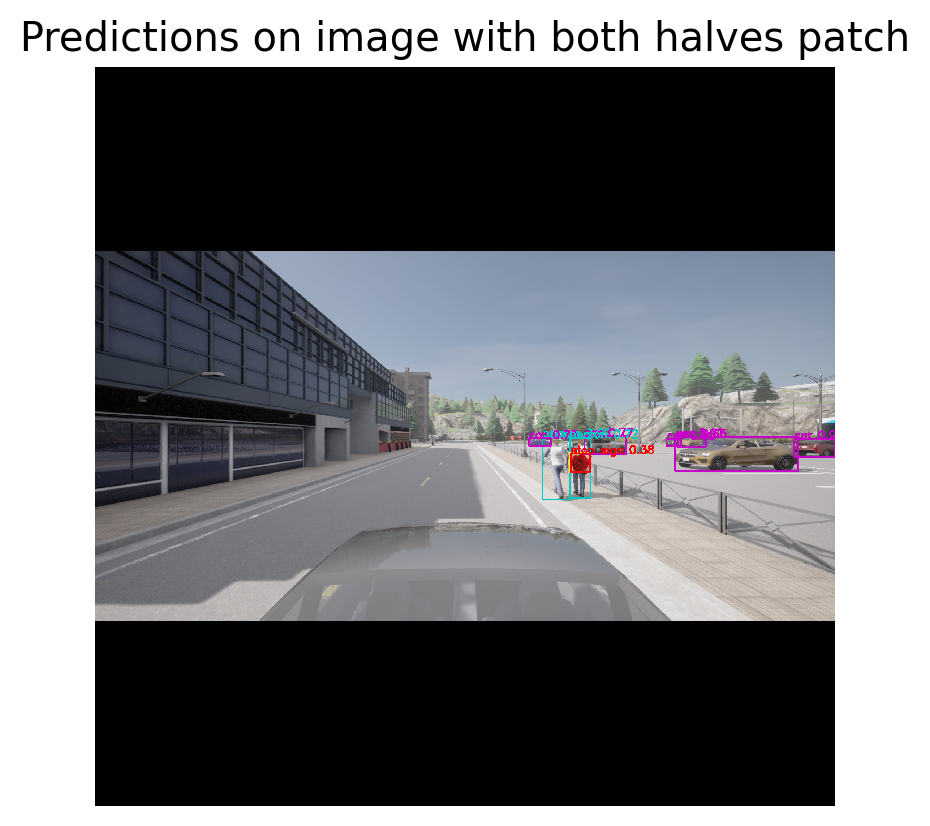

In [ ]:
%matplotlib inline

if True:
    patch=np.array(Image.open("patch_as_camellia_3.png")) # load external patch
    patch = patch.transpose(2,0,1)


classes = ["stop sign", "banana", "person", "car", "truck", "traffic light"]
#classes = ["stop sign", ]

n_boxes = 60
colordict =  {"stop sign":(255, 0, 0), "banana": (0,0,255), "car":(200, 0, 200), "person":(0, 200, 200)}
plot_threshold = 0.2
SCALE = scale_max
SKIP = 0
TRY_HALF_PATCH = False
PLOT_N_SAMPLES = 3
SHOW_IMAGES = False


detector = create_detector_model()

detector.model.eval() # TODO this should turn on non max suppression??? doesnt work

def load_and_transform_image(url):
    im = Image.open(url)
    return transform(im).numpy()

def batch_predict(urls, batch_size):
    all_predictions = []
    for i in range(0, len(urls), batch_size):
        batch_urls = urls[i:i + batch_size]
        batch_images = np.array([load_and_transform_image(url) for url in batch_urls])*255
        batch_dets = detector.predict(batch_images)
        all_predictions.extend(batch_dets)
    return all_predictions

def get_images(urls):
    images = np.array([load_and_transform_image(url) for url in urls])*255
    return images

def batch_predict_raw(imgs, batch_size=1):
    all_predictions = []
    for i in range(0, len(imgs), batch_size):
        batch_imgs = imgs[i:i + batch_size]
        batch_dets = detector.predict(batch_imgs)
        all_predictions.extend(batch_dets)
    return all_predictions

cut_urls = validation_urls[:DATASET_CUTOFF if DATASET_CUTOFF>0 and DATASET_CUTOFF<=len(urls) else len(urls)]
#sampled_urls = random.sample(cut_urls, PLOT_N_SAMPLES if PLOT_N_SAMPLES > 0 and PLOT_N_SAMPLES <= len(cut_urls) else len(cut_urls))
show_indices = set(random.sample(range(len(cut_urls) + 1), PLOT_N_SAMPLES))

set_seed()
dets_orig = batch_predict(cut_urls, batch_size)
preds_orig_person = [extract_predictions(dets, plot_threshold, n_boxes=n_boxes, classes=["person"]) for dets in dets_orig]

number_of_attacks = 0
successful_attacks = 0
successful_attacks_l = 0
successful_attacks_r = 0
success_threshold = 0.25

DEBUG = False

for j in tqdm(range(len(cut_urls)), desc="val steps"):
    if DEBUG: print("1")
    training_images = get_images(cut_urls[j:j+1])
    if DEBUG: print("2")
    
    if DEBUG: print("3 len(training_images)", len(training_images))
    if DEBUG: print("len(dets_orig)", len(dets_orig))
    if DEBUG: print(type(preds_orig_person[j:j+1]), preds_orig_person[j:j+1])
    if DEBUG: print("====")
    if DEBUG: print(preds_orig_person[i:i+1])
    if split:
        if TRY_HALF_PATCH:
            patched_images_l = ap.apply_patch(training_images[:], scale=SCALE, patch_external=patch, split=split, split_keep_both=False, half_to_keep="left", patch_locations=preds_orig_person[j:j+1])
            dets_l = batch_predict_raw(patched_images_l)
            #dets_l = detector.predict(patched_images_l)

            patched_images_r = ap.apply_patch(training_images[:], scale=SCALE, patch_external=patch, split=split, split_keep_both=False, half_to_keep="right", patch_locations=preds_orig_person[j:j+1])
            dets_r = batch_predict_raw(patched_images_r)
            #dets_r = detector.predict(patched_images_r)


        if DEBUG: print("\n\n\n")
        set_seed()
        patched_images, target_boxes = ap.apply_patch(training_images[:], scale=SCALE, patch_external=patch, split=split, split_keep_both=True, return_patch_outlines=True, patch_locations=preds_orig_person[j:j+1]) # , locations = 
    else:
        set_seed()
        patched_images, target_boxes = ap.apply_patch(training_images[:], scale=SCALE, patch_external=patch, split=split, split_keep_both=True, return_patch_outlines=True, patch_locations=preds_orig_person[j:j+1])

    set_seed()
    dets = batch_predict_raw(patched_images)






    for i in range(len(dets)):
        SHOW_IMAGES = False
        if j in show_indices:
            SHOW_IMAGES = True
        
        number_of_attacks += 1
        if i<SKIP:
            continue
        preds_orig = extract_predictions(dets_orig[i], plot_threshold, n_boxes=n_boxes, classes=classes)
        #if SHOW_IMAGES:
        #    plot_image_with_boxes(img=training_images[i].transpose(1,2,0).copy(), boxes=preds_orig[1], pred_cls=preds_orig[0],
        #                        title="Predictions on image without patch", scores=preds_orig[2], colordict=colordict)
        
        preds = extract_predictions(dets[i], plot_threshold, n_boxes=n_boxes, classes=classes)
        preds_stop_sign = extract_predictions(dets[i], success_threshold, n_boxes=n_boxes, classes=["stop sign"])
        if preds_stop_sign[0]:
            successful_attacks += 1
        if DEBUG: print("preds_stop_sign", preds_stop_sign)
        if SHOW_IMAGES:
            plot_image_with_boxes(img=patched_images[i].transpose(1,2,0).copy(), boxes=preds[1], pred_cls=preds[0], target_boxes=target_boxes[i],
                                title=f"Predictions on image with both halves patch", scores=preds[2], colordict=colordict)
        if split and TRY_HALF_PATCH:
            preds = extract_predictions(dets_l[i], plot_threshold, n_boxes=n_boxes, classes=classes)
            if SHOW_IMAGES:
                plot_image_with_boxes(img=patched_images_l[i].transpose(1,2,0).copy(), boxes=preds[1], pred_cls=preds[0],
                                    title="Predictions on image with left half of patch", scores=preds[2], colordict=colordict)
            preds = extract_predictions(dets_r[i], plot_threshold, n_boxes=n_boxes, classes=classes)
            if SHOW_IMAGES:
                plot_image_with_boxes(img=patched_images_r[i].transpose(1,2,0).copy(), boxes=preds[1], pred_cls=preds[0],
                                    title="Predictions on image with right half of patch", scores=preds[2], colordict=colordict)

print("========================")
print("STATS for threshold", success_threshold)
print("Number of attacks:", number_of_attacks)
print("Successful attacks:", successful_attacks)
print("Success rate:", successful_attacks/number_of_attacks)

Comparison to using the original disguise:



val steps: 100%|██████████| 304/304 [04:34<00:00,  1.11it/s]


STATS
Number of attacks: 304
Successful attacks: 44
Success rate: 0.14473684210526316


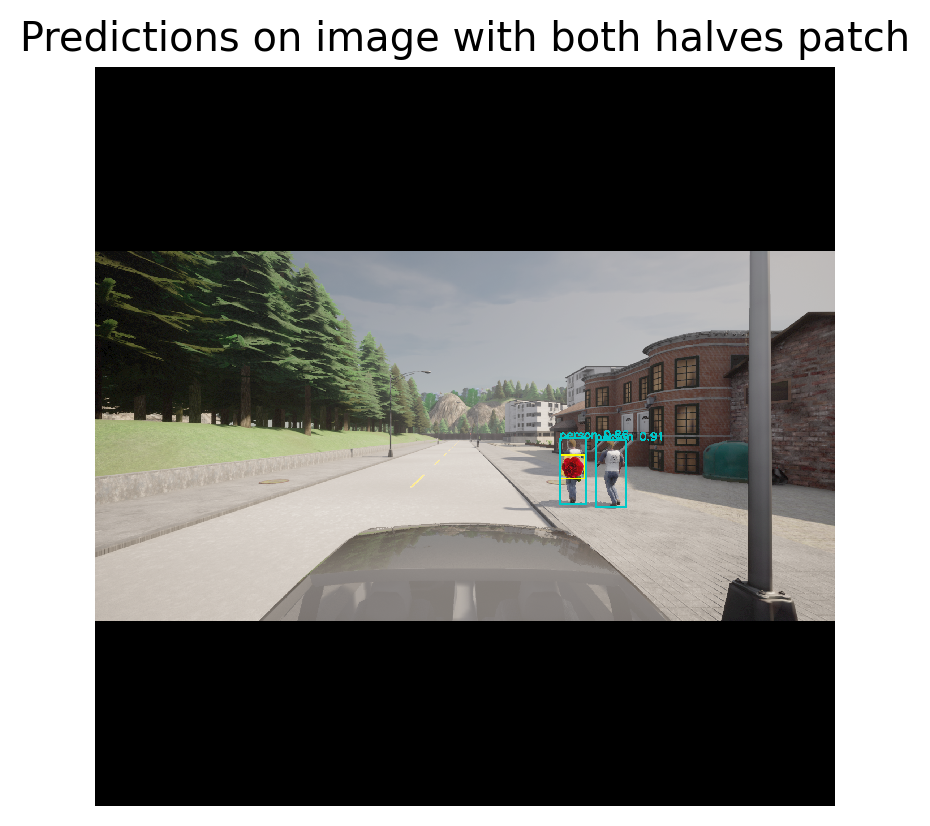

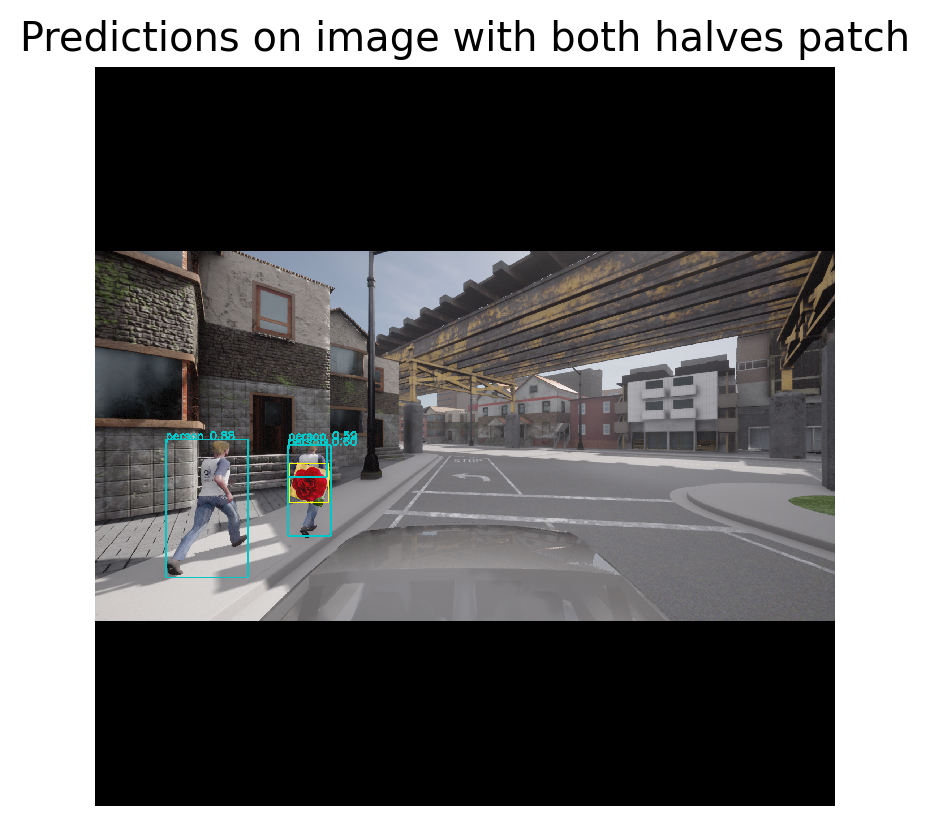

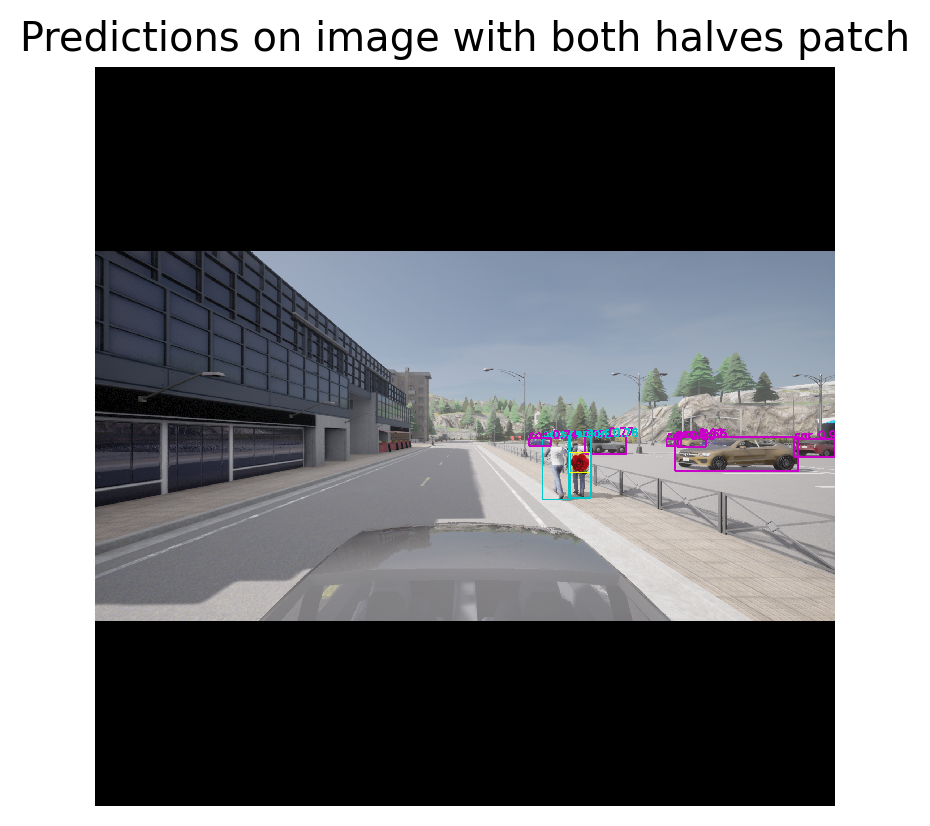

In [50]:
%matplotlib inline

patch=np.array(Image.open(DISGUISE_PATH)) # load external patch
patch = patch.transpose(2,0,1)

detector = create_detector_model()

detector.model.eval() # TODO this should turn on non max suppression??? doesnt work

def load_and_transform_image(url):
    im = Image.open(url)
    return transform(im).numpy()

def batch_predict(urls, batch_size):
    all_predictions = []
    for i in range(0, len(urls), batch_size):
        batch_urls = urls[i:i + batch_size]
        batch_images = np.array([load_and_transform_image(url) for url in batch_urls])*255
        batch_dets = detector.predict(batch_images)
        all_predictions.extend(batch_dets)
    return all_predictions

def get_images(urls):
    images = np.array([load_and_transform_image(url) for url in urls])*255
    return images

def batch_predict_raw(imgs, batch_size=1):
    all_predictions = []
    for i in range(0, len(imgs), batch_size):
        batch_imgs = imgs[i:i + batch_size]
        batch_dets = detector.predict(batch_imgs)
        all_predictions.extend(batch_dets)
    return all_predictions

cut_urls = validation_urls[:DATASET_CUTOFF if DATASET_CUTOFF>0 and DATASET_CUTOFF<=len(urls) else len(urls)]
#sampled_urls = random.sample(cut_urls, PLOT_N_SAMPLES if PLOT_N_SAMPLES > 0 and PLOT_N_SAMPLES <= len(cut_urls) else len(cut_urls))
show_indices = set(random.sample(range(len(cut_urls) + 1), PLOT_N_SAMPLES))

set_seed()
dets_orig = batch_predict(cut_urls, batch_size)
preds_orig_person = [extract_predictions(dets, plot_threshold, n_boxes=n_boxes, classes=["person"]) for dets in dets_orig]

number_of_attacks = 0
successful_attacks = 0
successful_attacks_l = 0
successful_attacks_r = 0
success_threshold = 0.25

DEBUG = False

for j in tqdm(range(len(cut_urls)), desc="val steps"):
    if DEBUG: print("1")
    training_images = get_images(cut_urls[j:j+1])
    if DEBUG: print("2")
    
    if DEBUG: print("3 len(training_images)", len(training_images))
    if DEBUG: print("len(dets_orig)", len(dets_orig))
    if DEBUG: print(type(preds_orig_person[j:j+1]), preds_orig_person[j:j+1])
    if DEBUG: print("====")
    if DEBUG: print(preds_orig_person[i:i+1])
    if split:
        if TRY_HALF_PATCH:
            patched_images_l = ap.apply_patch(training_images[:], scale=SCALE, patch_external=patch, split=split, split_keep_both=False, half_to_keep="left", patch_locations=preds_orig_person[j:j+1])
            dets_l = batch_predict_raw(patched_images_l)
            #dets_l = detector.predict(patched_images_l)

            patched_images_r = ap.apply_patch(training_images[:], scale=SCALE, patch_external=patch, split=split, split_keep_both=False, half_to_keep="right", patch_locations=preds_orig_person[j:j+1])
            dets_r = batch_predict_raw(patched_images_r)
            #dets_r = detector.predict(patched_images_r)


        if DEBUG: print("\n\n\n")
        set_seed()
        patched_images, target_boxes = ap.apply_patch(training_images[:], scale=SCALE, patch_external=patch, split=split, split_keep_both=True, return_patch_outlines=True, patch_locations=preds_orig_person[j:j+1]) # , locations = 
    else:
        set_seed()
        patched_images, target_boxes = ap.apply_patch(training_images[:], scale=SCALE, patch_external=patch, split=split, split_keep_both=True, return_patch_outlines=True, patch_locations=preds_orig_person[j:j+1])

    set_seed()
    dets = batch_predict_raw(patched_images)






    for i in range(len(dets)):
        SHOW_IMAGES = False
        if j in show_indices:
            SHOW_IMAGES = True
        
        number_of_attacks += 1
        if i<SKIP:
            continue
        preds_orig = extract_predictions(dets_orig[i], plot_threshold, n_boxes=n_boxes, classes=classes)
        #if SHOW_IMAGES:
        #    plot_image_with_boxes(img=training_images[i].transpose(1,2,0).copy(), boxes=preds_orig[1], pred_cls=preds_orig[0],
        #                        title="Predictions on image without patch", scores=preds_orig[2], colordict=colordict)
        
        preds = extract_predictions(dets[i], plot_threshold, n_boxes=n_boxes, classes=classes)
        preds_stop_sign = extract_predictions(dets[i], success_threshold, n_boxes=n_boxes, classes=["stop sign"])
        if preds_stop_sign[0]:
            successful_attacks += 1
        if DEBUG: print("preds_stop_sign", preds_stop_sign)
        if SHOW_IMAGES:
            plot_image_with_boxes(img=patched_images[i].transpose(1,2,0).copy(), boxes=preds[1], pred_cls=preds[0], target_boxes=target_boxes[i],
                                title=f"Predictions on image with both halves patch", scores=preds[2], colordict=colordict)
        if split and TRY_HALF_PATCH:
            preds = extract_predictions(dets_l[i], plot_threshold, n_boxes=n_boxes, classes=classes)
            if SHOW_IMAGES:
                plot_image_with_boxes(img=patched_images_l[i].transpose(1,2,0).copy(), boxes=preds[1], pred_cls=preds[0],
                                    title="Predictions on image with left half of patch", scores=preds[2], colordict=colordict)
            preds = extract_predictions(dets_r[i], plot_threshold, n_boxes=n_boxes, classes=classes)
            if SHOW_IMAGES:
                plot_image_with_boxes(img=patched_images_r[i].transpose(1,2,0).copy(), boxes=preds[1], pred_cls=preds[0],
                                    title="Predictions on image with right half of patch", scores=preds[2], colordict=colordict)

print("========================")
print("STATS")
print("STATS for threshold", success_threshold)
print("Successful attacks:", successful_attacks)
print("Success rate:", successful_attacks/number_of_attacks)

In [40]:
training_images.shape

(30, 3, 2048, 2048)

In [41]:
patched_images.shape

(30, 3, 2048, 2048)

In [42]:
ap._patch

tensor([[[208.98656, 203.88156, 190.47046,  ..., 234.66658, 233.28606, 231.42694],
         [226.73247, 216.64838, 200.76445,  ..., 217.76149, 211.65367, 215.06560],
         [225.14908, 208.51811, 189.52850,  ..., 215.02286, 202.98055, 218.46255],
         ...,
         [238.51041, 253.13560, 250.75040,  ...,  23.31985,  61.22847,  48.31509],
         [250.43965, 250.54359, 244.35063,  ...,  60.12952,  37.73705,  49.34317],
         [246.71701, 247.54118, 245.26797,  ...,  41.57444,  36.36920,  51.41037]],

        [[202.67804, 201.58781, 178.13553,  ..., 195.20763, 203.75772, 200.56985],
         [199.81673, 200.05180, 173.25279,  ..., 185.54529, 187.10091, 192.51477],
         [194.66826, 187.75967, 167.05194,  ..., 168.32581, 175.56165, 178.92285],
         ...,
         [229.14771, 226.83020, 225.27550,  ...,  72.13731,  67.10411,  70.67781],
         [234.10336, 229.52751, 232.81058,  ...,  81.74921,  56.25629,  66.91165],
         [233.86023, 233.63138, 224.65735,  ...,  90.5266

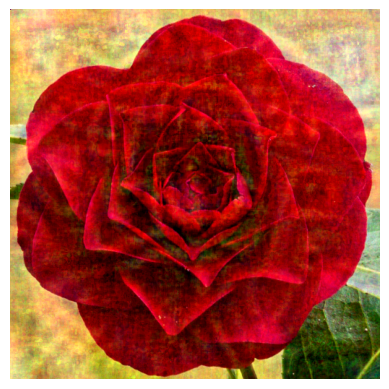

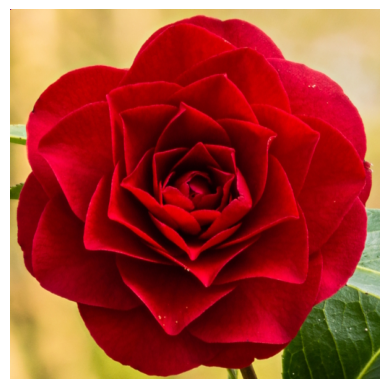

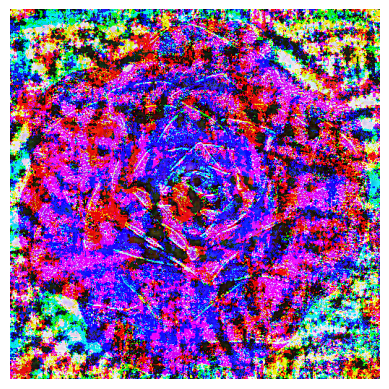

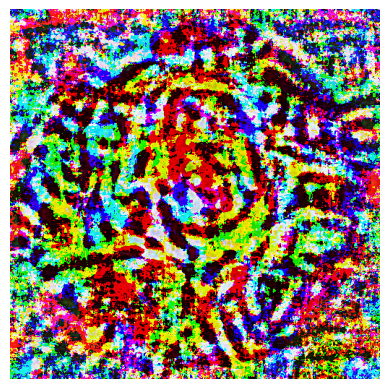

In [43]:
def show_image(tensor):
    # Use torchvision's ToPILImage to convert tensor to PIL image
    to_pil = transforms.ToPILImage()
    tensor = np.abs(tensor)
    tensor[:, 0, 0] = (0, 0, 0)
    tensor[:, 0, 1] = (255, 0, 255)
    img = to_pil(tensor.transpose(1,2,0))
    
    # Use matplotlib to display the image
    plt.imshow(img, cmap='gray')
    plt.axis('off')  # Turn off axis numbers and ticks
    plt.show()

show_image(ap._patch.cpu().detach().numpy().astype(np.uint8))
show_image(pretrained_patch.astype(np.uint8))
show_image(ap._patch.cpu().detach().numpy().astype(np.uint8) - pretrained_patch)
show_image(pretrained_patch - ap._patch.cpu().detach().numpy().astype(np.uint8))